
#  TPS-11-2021: Catboost
## Table of Contents
* [1. Overview](#1.)
* [2. Setup](#2.)
* [3. Exploratory Data Analysis & Preprocessing](#3.)
	* [3.1 Statistic Info](#3.1)
	* [3.2 Correlation Score](#3.2)
	* [3.3 Distribution of Label](#3.3)
	* [3.4 Drop ID column](#3.4)
	* [3.5 Train Validation Split](#3.5)
* [4. Model Development](#4.)
* [5. Submission](#5.)

<a id="1."></a>
## 1. Overview
In this Notebook, I will build a Tabular Prediciton Model using Catboost.
<a id="2."></a>
## 2. Setup

In [1]:
import numpy as np
import pandas as pd
try:
  from catboost import CatBoostClassifier
except:
  !pip install catboost
  from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
import os
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
class Config:
    is_kaggle_platform = os.path.exists("/kaggle/input")
    dataset_name = "tabular-playground-series-nov-2021"
    data_path = "/kaggle/input/%s/"%(dataset_name) if is_kaggle_platform else ""
    submit_filename = "submission.csv"
    label_name = "target"
config = Config()

In [3]:
if not config.is_kaggle_platform:
  try:
    import kaggle
  except:
    !pip install kaggle
  if not os.path.exists("/root/.kaggle/kaggle.json"):
    !echo "{"username":"{your username}","key":"{your apikey}"}" >> /root/.kaggle/kaggle.json
    !chmod 600 /root/.kaggle/kaggle.json
  !kaggle competitions download -c $config.dataset_name
  !unzip test.csv.zip
  !unzip train.csv.zip
  !unzip sample_submission.csv.zip

In [4]:
train = pd.read_csv(config.data_path + "train.csv")
test = pd.read_csv(config.data_path + "test.csv")
sample_submission = pd.read_csv(config.data_path + "sample_submission.csv")


<a id="3."></a>
## 3. Exploratory Data Analysis & Preprocessing

In [5]:
train.head()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
0,0,0.106643,3.59437,132.8040,3.18428,0.081971,1.18859,3.73238,2.266270,2.09959,...,1.09862,0.013331,-0.011715,0.052759,0.065400,4.211250,1.97877,0.085974,0.240496,0
1,1,0.125021,1.67336,76.5336,3.37825,0.099400,5.09366,1.27562,-0.471318,4.54594,...,3.46017,0.017054,0.124863,0.154064,0.606848,-0.267928,2.57786,-0.020877,0.024719,0
2,2,0.036330,1.49747,233.5460,2.19435,0.026914,3.12694,5.05687,3.849460,1.80187,...,4.88300,0.085222,0.032396,0.116092,-0.001688,-0.520069,2.14112,0.124464,0.148209,0
3,3,-0.014077,0.24600,779.9670,1.89064,0.006948,1.53112,2.69800,4.517330,4.50332,...,3.47439,-0.017103,-0.008100,0.062013,0.041193,0.511657,1.96860,0.040017,0.044873,0
4,4,-0.003259,3.71542,156.1280,2.14772,0.018284,2.09859,4.15492,-0.038236,3.37145,...,1.91059,-0.042943,0.105616,0.125072,0.037509,1.043790,1.07481,-0.012819,0.072798,1


<a id="3.1"></a>
### 3.1 Statistic Info

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Columns: 102 entries, id to target
dtypes: float64(100), int64(2)
memory usage: 466.9 MB


In [7]:
train.describe()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
count,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,...,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000
mean,299999.500000,0.306508,2.497590,306.644536,2.647901,0.177850,2.556832,2.699650,2.571593,2.538273,...,2.444471,0.155260,0.059407,0.144932,0.106419,2.547853,2.590159,0.158881,0.123048,0.506010
std,173205.225094,0.522450,1.554018,551.743893,1.544529,0.417488,1.562527,1.564000,1.549361,1.532988,...,1.542509,0.548397,0.119426,0.462015,0.209128,1.558427,1.525091,0.436190,0.264896,0.499964
min,0.000000,-3.797450,-1.223960,-1842.530000,-1.368560,-3.206210,-1.169770,-1.059310,-1.281970,-1.242020,...,-1.217700,-9.761770,-4.666240,-3.101500,-1.276540,-1.584740,-1.254730,-3.993500,-2.783380,0.000000
25%,149999.750000,0.026222,1.186238,43.573400,1.442028,0.019709,1.261038,1.385820,1.333848,1.292163,...,1.214178,0.018904,0.024483,0.017055,0.025461,1.247888,1.348078,0.013536,0.018105,0.000000
50%,299999.500000,0.097788,2.516500,133.626000,2.634130,0.061586,2.590425,2.801255,2.557985,2.475880,...,2.386845,0.068906,0.056649,0.063439,0.062151,2.601940,2.682090,0.058058,0.058471,1.000000
75%,449999.250000,0.397184,3.787630,302.262250,3.907640,0.112712,3.813662,3.996913,3.823450,3.804360,...,3.693872,0.125165,0.088162,0.113114,0.102016,3.820665,3.839520,0.110718,0.104872,1.000000
max,599999.000000,8.781500,6.226720,6119.280000,6.521150,8.265470,6.515070,6.586780,6.258770,6.389670,...,6.573890,18.412800,10.211800,8.623270,3.657220,6.254360,6.145300,10.767000,5.988110,1.000000


<a id="3.2"></a>
### 3.2 Correlation Score

In [8]:
corr = train.corr()
corr

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
id,1.000000,-0.019128,-0.000611,0.049249,-0.024055,-0.042858,0.101671,-0.000429,0.068104,-0.036948,...,-0.091920,0.018084,-0.029640,0.007519,-0.027229,0.116687,0.002677,0.022160,-0.027536,0.063100
f0,-0.019128,1.000000,0.005288,-0.002627,-0.003714,0.013101,-0.002081,-0.004594,-0.003715,-0.007836,...,-0.002431,-0.003203,0.000666,-0.005514,-0.001556,-0.014159,-0.016717,0.000539,0.008145,0.001653
f1,-0.000611,0.005288,1.000000,0.009679,-0.014078,-0.001013,0.008854,0.004880,-0.002326,0.020885,...,-0.002975,-0.007733,0.006767,-0.009169,0.003269,0.012188,0.002068,0.002157,0.002548,-0.025762
f2,0.049249,-0.002627,0.009679,1.000000,-0.002295,-0.015797,0.011925,-0.000030,-0.004807,0.006432,...,0.001939,0.000458,0.005432,0.002372,0.002854,0.002000,-0.001779,-0.001412,-0.001729,-0.023432
f3,-0.024055,-0.003714,-0.014078,-0.002295,1.000000,-0.010610,-0.021345,0.000324,0.000108,-0.003198,...,0.011295,-0.004317,-0.000742,0.005074,0.020866,-0.007060,0.009756,-0.010952,0.000703,-0.041314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
f96,0.116687,-0.014159,0.012188,0.002000,-0.007060,-0.002618,0.012564,0.004777,0.019258,-0.003765,...,-0.017331,0.004584,-0.000846,-0.002894,-0.004823,1.000000,-0.007190,-0.001376,-0.008083,0.059307
f97,0.002677,-0.016717,0.002068,-0.001779,0.009756,-0.011757,-0.006829,-0.015344,-0.002281,-0.001995,...,0.006754,0.002675,-0.000117,0.008985,-0.003586,-0.007190,1.000000,-0.002561,0.002204,-0.080727
f98,0.022160,0.000539,0.002157,-0.001412,-0.010952,0.012426,0.008329,-0.001864,-0.001392,0.006603,...,-0.005145,-0.008048,-0.005267,-0.002564,-0.003504,-0.001376,-0.002561,1.000000,-0.006297,0.047160
f99,-0.027536,0.008145,0.002548,-0.001729,0.000703,0.002732,0.007394,0.009251,0.006628,-0.008832,...,0.002562,0.003759,-0.002089,0.003564,-0.009223,-0.008083,0.002204,-0.006297,1.000000,-0.011223


In [9]:
corr.sort_values(ascending=False, inplace=True, by=config.label_name, key= lambda x: abs(x))
corr[config.label_name]

target    1.000000
f34       0.135270
f55      -0.113889
f43       0.109418
f71      -0.107687
            ...   
f0        0.001653
f72      -0.001339
f38      -0.000519
f52       0.000380
f65      -0.000084
Name: target, Length: 102, dtype: float64

In [10]:
correlated_columns = corr[config.label_name][corr[config.label_name].abs() > 0.05].index
correlated_columns, len(correlated_columns)

(Index(['target', 'f34', 'f55', 'f43', 'f71', 'f80', 'f91', 'f8', 'f27', 'f97',
        'f50', 'f41', 'f57', 'f25', 'f22', 'f66', 'id', 'f96', 'f81', 'f82',
        'f21', 'f40'],
       dtype='object'),
 22)

In [11]:
correlation_score = train.corr()
correlated_features = correlation_score[config.label_name].sort_values(ascending=False).dropna()
correlated_columns = list(correlated_features[correlated_features.abs() > 0.05].index)
correlated_columns.remove(config.label_name)
print(correlated_columns)

['f34', 'f43', 'f8', 'f27', 'f50', 'f41', 'f57', 'id', 'f96', 'f81', 'f40', 'f21', 'f82', 'f66', 'f22', 'f25', 'f97', 'f91', 'f80', 'f71', 'f55']


In [12]:
corr2 = train[correlated_columns].corr()
corr2

,f34,f43,f8,f27,f50,f41,f57,id,f96,f81,...,f21,f82,f66,f22,f25,f97,f91,f80,f71,f55
f34,1.000000,0.014907,0.003081,0.022298,0.029479,0.007064,0.005551,0.018688,-0.007030,0.013411,...,-0.040018,-0.007987,-0.001578,-0.000153,-0.016713,-0.024340,0.000247,-0.020025,-0.025901,-0.013517
f43,0.014907,1.000000,0.008958,0.032525,0.006781,0.006113,0.010827,0.109330,0.004264,0.010010,...,0.001685,-0.000956,0.018917,0.013893,-0.023229,-0.000798,-0.018433,-0.033338,-0.004328,-0.010727
f8,0.003081,0.008958,1.000000,0.011797,0.008406,0.015885,0.000048,-0.036948,-0.003765,0.009622,...,-0.002480,0.009933,-0.016484,-0.007472,-0.017650,-0.001995,-0.005702,-0.007565,-0.024717,-0.008150
f27,0.022298,0.032525,0.011797,1.000000,0.017581,0.006763,0.008884,0.086378,-0.007455,-0.014113,...,-0.001954,0.013341,0.005859,-0.009534,-0.010791,-0.013606,-0.017576,-0.019809,-0.013499,-0.023431
f50,0.029479,0.006781,0.008406,0.017581,1.000000,-0.004489,0.011914,0.043041,0.011292,0.002570,...,-0.000053,0.002178,-0.003521,0.000285,0.000584,-0.003095,0.007200,-0.013377,-0.001755,-0.001002
f41,0.007064,0.006113,0.015885,0.006763,-0.004489,1.000000,0.003421,-0.026966,0.007592,0.006318,...,-0.020604,0.009033,-0.004259,-0.019668,0.010040,-0.011546,-0.001279,-0.008937,-0.014439,0.003193
f57,0.005551,0.010827,0.000048,0.008884,0.011914,0.003421,1.000000,0.078273,0.018536,0.004354,...,-0.007217,-0.002590,-0.015619,-0.005228,-0.000880,-0.007430,-0.028483,-0.007979,-0.001182,-0.005375
id,0.018688,0.109330,-0.036948,0.086378,0.043041,-0.026966,0.078273,1.000000,0.116687,0.025711,...,-0.030268,0.074681,0.037245,0.008106,-0.042891,0.002677,-0.091920,-0.049232,-0.001764,-0.040457
f96,-0.007030,0.004264,-0.003765,-0.007455,0.011292,0.007592,0.018536,0.116687,1.000000,-0.004946,...,-0.026302,0.012180,-0.007586,-0.004307,0.009885,-0.007190,-0.017331,-0.001064,-0.004011,-0.002335
f81,0.013411,0.010010,0.009622,-0.014113,0.002570,0.006318,0.004354,0.025711,-0.004946,1.000000,...,-0.016596,-0.016897,0.000939,-0.010229,-0.010552,-0.019470,-0.012010,-0.004164,-0.023760,-0.010428


<AxesSubplot:>

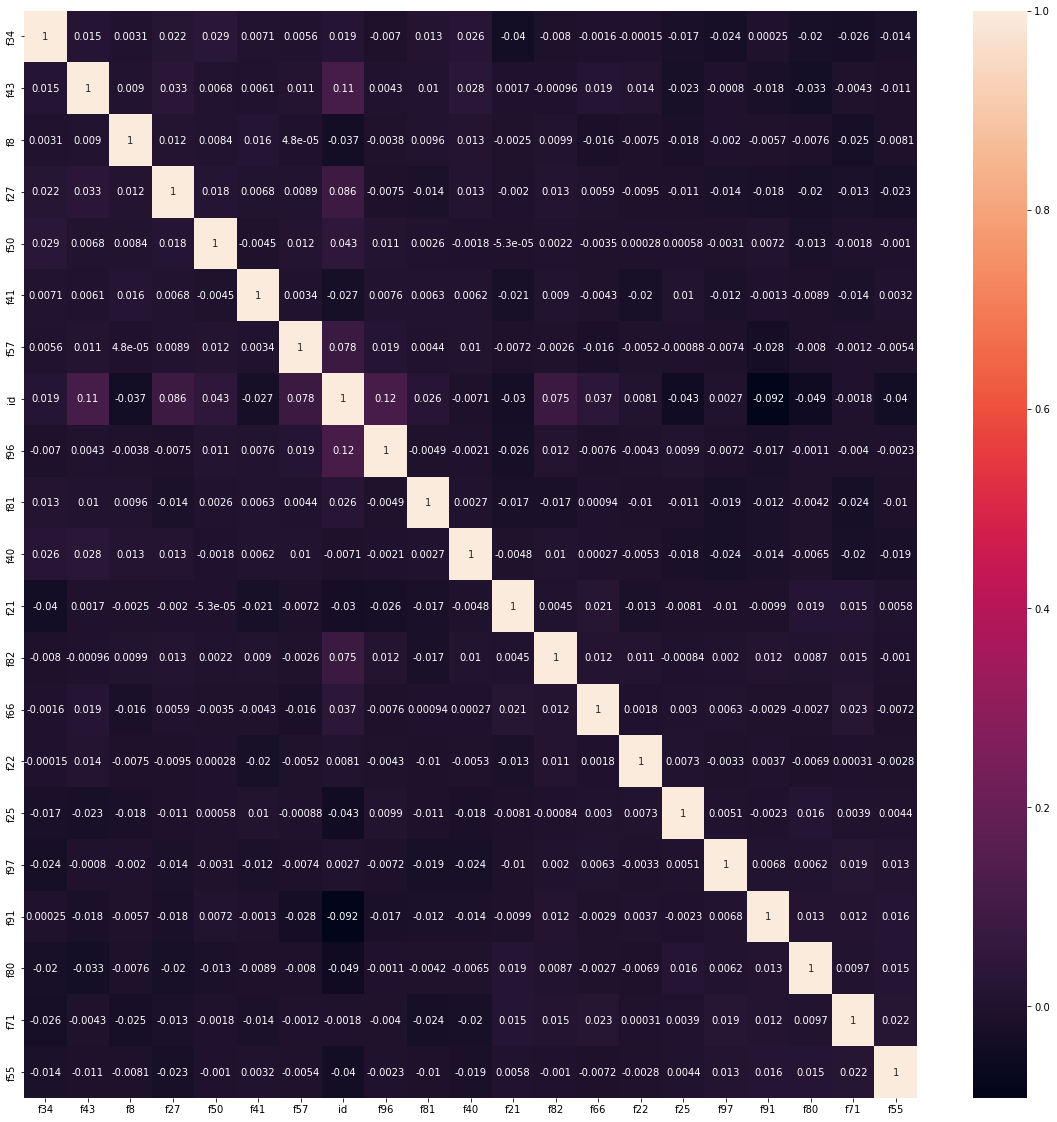

In [13]:
plt.figure(figsize=(20, 20))
sns.heatmap(corr2, annot=True)

<a id="3.3"></a>
### 3.3 Distribution of Label

<AxesSubplot:xlabel='target', ylabel='count'>

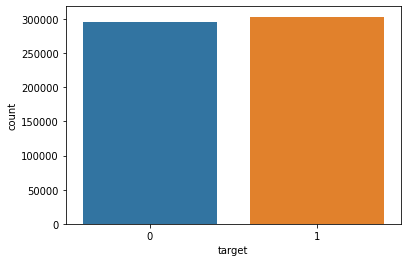

In [14]:
sns.countplot(x=config.label_name, data=train)

<a id="3.4"></a>
### 3.4 Drop ID column
ID is not needed. So remove this column.

In [15]:
train.pop("id")
_ = test.pop("id")

<a id="3.5"></a>
### 3.5 Train Validation Split

In [16]:
train_features, val_features = train_test_split(train, test_size=0.15, random_state=42)
train_targets = train_features.pop(config.label_name)
val_targets = val_features.pop(config.label_name)
train_features.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99
138398,0.039311,3.755520,-15.77520,3.474750,0.004473,2.109650,0.666355,2.85475,2.413630,0.055412,...,0.124539,2.17396,0.034133,0.125402,0.008173,0.445494,-0.205071,3.14453,0.045849,-0.018523
541294,0.069908,3.266390,-64.77950,-0.191486,0.135202,1.975170,1.550490,2.90427,4.385780,0.023049,...,0.003446,3.58612,0.127069,-0.002538,0.100642,0.012687,1.410450,3.76337,0.026219,0.051769
342929,0.005676,0.851164,3989.90000,5.130630,0.027197,4.373280,3.013990,3.63893,3.806900,0.257983,...,0.002493,5.16411,0.077312,0.112086,0.093566,0.030684,1.003830,2.19868,0.099238,0.247694
467290,1.092640,1.410520,3.86633,2.849660,-0.022414,3.335880,4.664550,3.31697,5.477050,0.072645,...,0.008147,3.22178,2.211560,-0.002075,1.011160,0.044214,1.443060,4.13734,-0.006603,0.014224
104731,0.022603,2.487390,8.97426,1.733760,0.091787,-0.081385,2.969110,2.52309,0.275419,0.010512,...,0.011336,2.66600,0.161324,0.085672,0.402956,0.123951,2.582670,1.69309,0.565830,0.212242


There isn't any missing value, not need for Data Wrangling

In [17]:
null_counts = train_features.isnull().sum()
print(null_counts[null_counts > 0])
null_counts = val_features.isnull().sum()
print(null_counts[null_counts > 0])

Series([], dtype: int64)
Series([], dtype: int64)


<a id="4."></a>
## 4. Model Development

In [18]:

cat_params = {
    'iterations': 15000,
    'objective': 'CrossEntropy',
    'bootstrap_type': 'Bernoulli',
    'od_wait': 1000,
    'learning_rate': 0.023575206684596582,
    'reg_lambda': 36.30433203563295,
    'random_strength': 43.75597655616195,
    'depth': 7,
    'min_data_in_leaf': 11,
    'leaf_estimation_iterations': 1,
    'subsample': 0.8227911142845009,
    'task_type' : 'GPU',
    'devices' : '0',
    'verbose' : 1000,
    'eval_metric': 'AUC'
}
cat = CatBoostClassifier(**cat_params)
cat.fit(train_features, train_targets, eval_set=(val_features, val_targets))


0:	learn: 0.6279791	test: 0.6276309	best: 0.6276309 (0)	total: 19.3ms	remaining: 4m 50s
1000:	learn: 0.7498618	test: 0.7436562	best: 0.7436562 (1000)	total: 13s	remaining: 3m 1s
2000:	learn: 0.7588231	test: 0.7475051	best: 0.7475051 (2000)	total: 26.5s	remaining: 2m 52s
3000:	learn: 0.7655697	test: 0.7485025	best: 0.7485037 (2998)	total: 39.3s	remaining: 2m 37s
4000:	learn: 0.7717718	test: 0.7489795	best: 0.7489795 (4000)	total: 53.1s	remaining: 2m 25s
5000:	learn: 0.7779719	test: 0.7492745	best: 0.7492788 (4931)	total: 1m 5s	remaining: 2m 11s
6000:	learn: 0.7840068	test: 0.7495514	best: 0.7495544 (5957)	total: 1m 18s	remaining: 1m 57s
7000:	learn: 0.7898899	test: 0.7496985	best: 0.7496994 (6998)	total: 1m 32s	remaining: 1m 45s
8000:	learn: 0.7957330	test: 0.7497348	best: 0.7497665 (7693)	total: 1m 44s	remaining: 1m 31s
bestTest = 0.7497665286
bestIteration = 7693
Shrink model to first 7694 iterations.


<a id="5."></a>
## 5. Submission

In [19]:
y_pred = cat.predict_proba(test)
sample_submission[config.label_name] = y_pred[:, 1]
sample_submission.to_csv(config.submit_filename, index=False)
if not config.is_kaggle_platform:
  !kaggle competitions submit $config.dataset_name -m "Submission" -f $config.submit_filename

**If you found my notebook useful, give me an upvote.**

You may have a look at some of my TPS notebooks before.

- [Tabular Playground Series Prediction(Aug 2021)](https://www.kaggle.com/lonnieqin/tabular-playground-series-prediction)
- [Tabular Playground Prediction(Sep 2021) with CatBoost](https://www.kaggle.com/lonnieqin/catboost-tabular-playground-prediction-sep-2021)
- [Tabular Prediction(Oct 2021) with CatBoost](https://www.kaggle.com/lonnieqin/catboost-tabular-prediction-oct-2021)
- [TPS Prediction with DNN and KerasTuner (Oct 2021)](https://www.kaggle.com/lonnieqin/tps-prediction-with-dnn-and-kerastuner-oct-2021)
- [TPS-10-21: DNN](https://www.kaggle.com/lonnieqin/tps-10-21-dnn)
